In [1]:
import gffpandas.gffpandas as gffpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ctrl_diff = pd.read_csv("./methyl_point_diff/ctrl_diff_all.csv")
ars_diff = pd.read_csv("./methyl_point_diff/arsS_diff_all.csv")
ph5_diff = pd.read_csv("./methyl_point_diff/pH5_diff_all.csv")
ph7_diff = pd.read_csv("./methyl_point_diff/pH7_diff_all.csv")

In [3]:
ctrl_diff

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,context,coverage,id,identificationQv,motif,Classification,promoter_ID,CodingRegion_ID,CodingRegion_gene_type,Promoter_gene_type
0,107,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,2946,2946,122,+,.,...,GCAAATGCCGCACTAGAATGCGCGAAATTAGACATTGACAT,544,NaN,59.0,NaN,Coding Region,NaN,HP0005,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES",NaN
1,191,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,modified_base,5835,5835,127,+,.,...,TTATGCCCTAATTCTTGCGTGGCGCTTAATAATTGCGAATA,521,NaN,NaN,NaN,Coding Region,NaN,HP0009,CELL ENVELOPE,NaN
2,195,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,6033,6033,108,+,.,...,CTAAAATCAAGTATCGTGCGCGCCAACAACTCAGATTGCTT,526,NaN,26.0,NaN,Coding Region,NaN,HP0009,CELL ENVELOPE,NaN
3,237,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,7151,7151,123,+,.,...,GGTGTTTTTCACCATTTGAGCGGCTTCACCGATTTGATAGC,511,NaN,66.0,NaN,Intergenic Region,NaN,NaN,NaN,NaN
4,258,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,7831,7831,127,+,.,...,CTAGCGTTAAAACCAAAATGCCCTTCGTGTTTTTCTACTTC,469,NaN,102.0,NaN,Coding Region,NaN,HP0010,CELLULAR PROCESSES,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1114,118679,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,modified_base,1648914,1648914,80,-,.,...,CATGACTAAAAAGGAATTTCTAGTCCCTACAAGGGGAAATA,436,NaN,NaN,NaN,Coding Region,NaN,HP1565,CELL ENVELOPE,NaN
1115,118761,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1651173,1651173,94,-,.,...,GATTAGTGTTTTTCTTTTTGCGTTCCCAACCCACTAGCGTA,444,NaN,59.0,NaN,Coding Region,NaN,HP1569,HYPOTHETICAL PROTEIN,NaN
1116,118876,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1653947,1653947,129,-,.,...,AAATTGCTGAAATCATCAACATAGAGACTGAAGAACTCGCT,434,NaN,86.0,NaN,Coding Region,NaN,HP1573,HYPOTHETICAL PROTEIN,NaN
1117,118897,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1654536,1654536,92,-,.,...,ACTCAATGCGTGATTCCTGGCGCGGACATGAAGGATTTGAA,432,NaN,48.0,NaN,Coding Region,NaN,HP1573,HYPOTHETICAL PROTEIN,NaN


### VacA Control Code

In [55]:
def plot_single_bar_with_highlight_relative(ctrl_diff, gene_start, gene_end):
    """
    Plot control sample differences along a gene using gene-relative (1-based)
    coordinates, with intermediate x-axis ticks and a legend.

    Parameters:
    ctrl_diff : DataFrame with columns ['start', 'end', 'sample']
    gene_start : genomic start of the gene
    gene_end   : genomic end of the gene
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.lines import Line2D

    # Filter data within gene boundaries
    filtered = ctrl_diff[
        (ctrl_diff['start'] >= gene_start) &
        (ctrl_diff['end'] <= gene_end)
    ].copy()

    if filtered.empty:
        print("No data in gene range")
        return

    # Convert genomic → gene-relative positions (+1 INCLUDED)
    filtered['relative_pos'] = filtered['start'] - gene_start + 1
    gene_length = gene_end - gene_start + 1

    # Create figure and axis (THIS is where `ax` comes from)
    fig, ax = plt.subplots(figsize=(11, 6))
    y_pos = 0

    # Plot tick marks
    for _, row in filtered.iterrows():
        if 'pH7' in str(row['sample']):
            color = 'darkgreen'
        elif 'pH5' in str(row['sample']):
            color = 'yellowgreen'
        else:
            color = 'gray'

        ax.plot(
            [row['relative_pos'], row['relative_pos']],
            [y_pos - 0.2, y_pos + 0.2],
            color=color,
            linewidth=4,
            alpha=0.8,
            solid_capstyle='butt'
        )

    # Baseline across gene
    ax.plot([1, gene_length], [y_pos, y_pos],
            color='black', linewidth=1, alpha=0.5)

    # Axis limits
    ax.set_xlim(1, gene_length)
    ax.set_ylim(-0.5, 0.5)

    # X-axis ticks: 1, intermediate values, and gene end
    tick_step = 250  # adjust if needed (e.g. 250, 1000)
    ticks = np.arange(1, gene_length + 1, tick_step)
    if gene_length not in ticks:
        ticks = np.append(ticks, gene_length)

    ax.set_xticks(ticks)
    ax.set_xticklabels([str(int(t)) for t in ticks])

    # Labels and title
    ax.set_xlabel('Coding Region of vacA')
    ax.set_title('$\it{vacA}$ – Gene-Relative methylation differences', fontsize=30)    
    ax.set_yticks([])
    ax.set_ylabel('Control Sample Differences')

    # Legend (key for sample type)
    legend_elements = [
        Line2D([0], [0], color='darkgreen', lw=4, label='Control pH7'),
        Line2D([0], [0], color='yellowgreen', lw=4, label='Control pH5')
    ]

    ax.legend(
        handles=legend_elements,
        title='Sample type',
        loc='upper right',
        frameon=False
    )

    plt.tight_layout()
    plt.show()


<>:70: SyntaxWarning: invalid escape sequence '\i'
<>:70: SyntaxWarning: invalid escape sequence '\i'
/var/folders/kw/19vs2__d3bl_tx91fly_4sg40000gn/T/ipykernel_25860/612693385.py:70: SyntaxWarning: invalid escape sequence '\i'
  ax.set_title('$\it{vacA}$ – Gene-Relative methylation differences', fontsize=30)


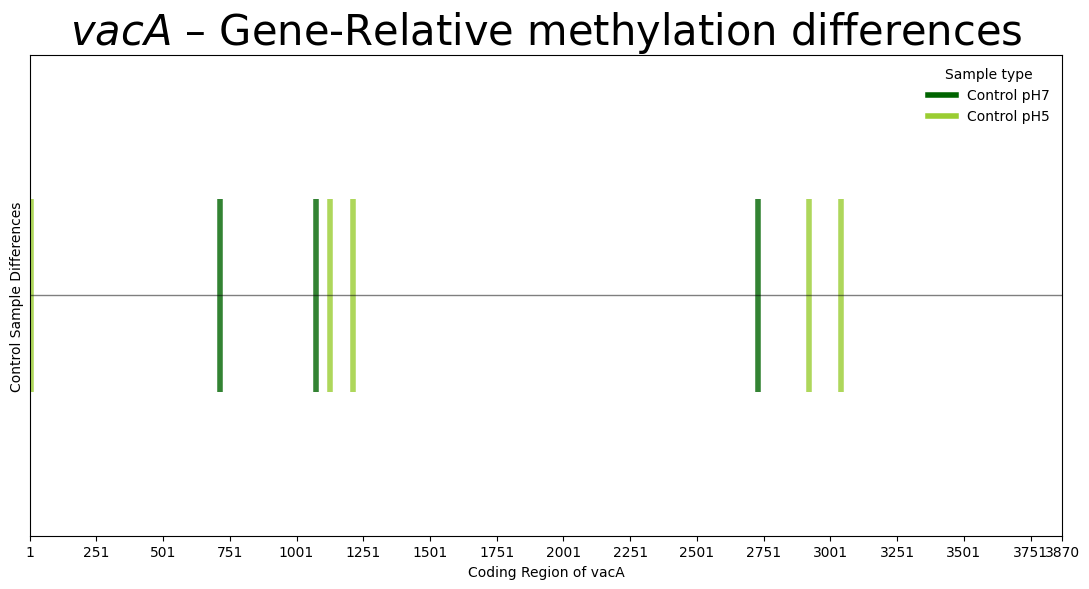

In [56]:
gene_start = 938415
gene_end = 942284

plot_single_bar_with_highlight_relative(ctrl_diff, gene_start, gene_end)


### sabA Control Code

In [57]:
def plot_single_bar_with_highlight_relative(ctrl_diff, gene_start, gene_end):
    """
    Plot control sample differences along a gene using gene-relative (1-based)
    coordinates, with intermediate x-axis ticks and a legend.

    Parameters:
    ctrl_diff : DataFrame with columns ['start', 'end', 'sample']
    gene_start : genomic start of the gene
    gene_end   : genomic end of the gene
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.lines import Line2D

    # Filter data within gene boundaries
    filtered = ctrl_diff[
        (ctrl_diff['start'] >= gene_start) &
        (ctrl_diff['end'] <= gene_end)
    ].copy()

    if filtered.empty:
        print("No data in gene range")
        return

    # Convert genomic → gene-relative positions (+1 INCLUDED)
    filtered['relative_pos'] = filtered['start'] - gene_start + 1
    gene_length = gene_end - gene_start + 1

    # Create figure and axis (THIS is where `ax` comes from)
    fig, ax = plt.subplots(figsize=(11, 6))
    y_pos = 0

    # Plot tick marks
    for _, row in filtered.iterrows():
        if 'pH7' in str(row['sample']):
            color = 'darkgreen'
        elif 'pH5' in str(row['sample']):
            color = 'yellowgreen'
        else:
            color = 'gray'

        ax.plot(
            [row['relative_pos'], row['relative_pos']],
            [y_pos - 0.2, y_pos + 0.2],
            color=color,
            linewidth=4,
            alpha=0.8,
            solid_capstyle='butt'
        )

    # Baseline across gene
    ax.plot([1, gene_length], [y_pos, y_pos],
            color='black', linewidth=1, alpha=0.5)

    # Axis limits
    ax.set_xlim(1, gene_length)
    ax.set_ylim(-0.5, 0.5)

    # X-axis ticks: 1, intermediate values, and gene end
    tick_step = 250  # adjust if needed (e.g. 250, 1000)
    ticks = np.arange(1, gene_length + 1, tick_step)
    if gene_length not in ticks:
        ticks = np.append(ticks, gene_length)

    ax.set_xticks(ticks)
    ax.set_xticklabels([str(int(t)) for t in ticks])

    # Labels and title
    ax.set_xlabel('Coding Region of sabA')
    ax.set_title('$\it{sabA}$ – Gene-Relative methylation differences', fontsize=30)    
    ax.set_yticks([])
    ax.set_ylabel('Control Sample Differences')

    # Legend (key for sample type)
    legend_elements = [
        Line2D([0], [0], color='darkgreen', lw=4, label='Control pH7'),
        Line2D([0], [0], color='yellowgreen', lw=4, label='Control pH5')
    ]

    ax.legend(
        handles=legend_elements,
        title='Sample type',
        loc='upper right',
        frameon=False
    )

    plt.tight_layout()
    plt.show()


<>:70: SyntaxWarning: invalid escape sequence '\i'
<>:70: SyntaxWarning: invalid escape sequence '\i'
/var/folders/kw/19vs2__d3bl_tx91fly_4sg40000gn/T/ipykernel_25860/2068083336.py:70: SyntaxWarning: invalid escape sequence '\i'
  ax.set_title('$\it{sabA}$ – Gene-Relative methylation differences', fontsize=30)


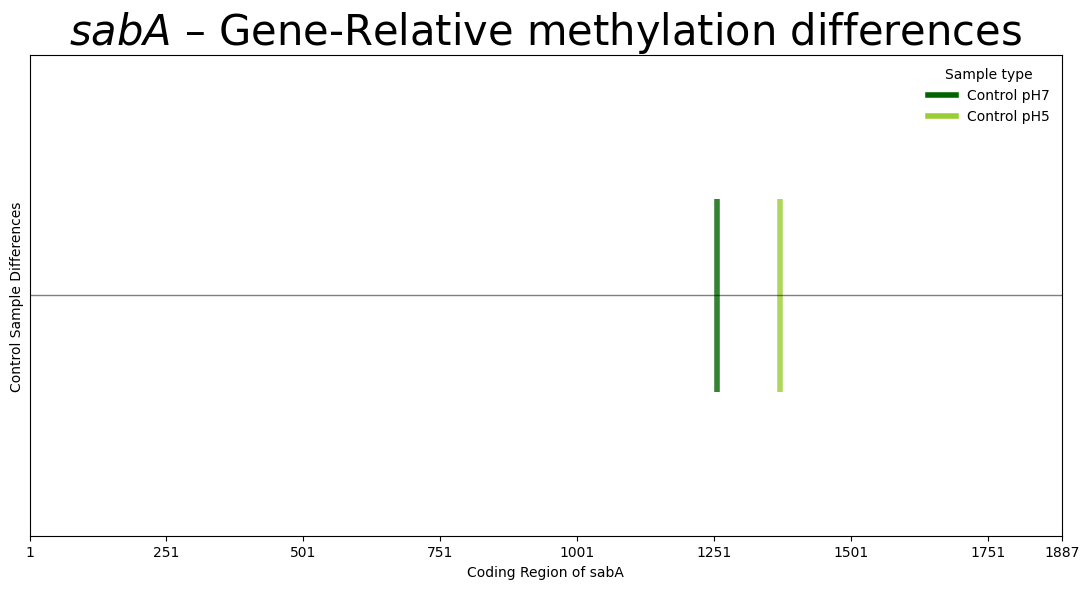

In [58]:
gene_start = 779011
gene_end = 780897


plot_single_bar_with_highlight_relative(ars_diff, gene_start, gene_end)

### sabA ArsS Code

In [61]:
def plot_single_bar_with_highlight_relative(ars_diff, gene_start, gene_end):
    """
    Plot control sample differences along a gene using gene-relative (1-based)
    coordinates, with intermediate x-axis ticks and a legend.

    Parameters:
    ctrl_diff : DataFrame with columns ['start', 'end', 'sample']
    gene_start : genomic start of the gene
    gene_end   : genomic end of the gene
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.lines import Line2D

    # Filter data within gene boundaries
    filtered = ars_diff[
        (ars_diff['start'] >= gene_start) &
        (ars_diff['end'] <= gene_end)
    ].copy()

    if filtered.empty:
        print("No data in gene range")
        return

    # Convert genomic → gene-relative positions (+1 INCLUDED)
    filtered['relative_pos'] = filtered['start'] - gene_start + 1
    gene_length = gene_end - gene_start + 1

    # Create figure and axis (THIS is where `ax` comes from)
    fig, ax = plt.subplots(figsize=(11, 6))
    y_pos = 0

    for idx, row in filtered.iterrows():
        # Determine color based on sample type
        if 'pH7' in str(row['sample']):
            color = 'maroon'
            label = 'del_arsS pH7'
        elif 'pH5' in str(row['sample']):
            color = 'indianred' 
            label = 'del_arsS pH5'
        else:
            color = 'gray'
            label = 'other'
        ax.plot(
            [row['relative_pos'], row['relative_pos']],
            [y_pos - 0.2, y_pos + 0.2],
            color=color,
            linewidth=4,
            alpha=0.8,
            solid_capstyle='butt'
        )

    # Baseline across gene
    ax.plot([1, gene_length], [y_pos, y_pos],
            color='black', linewidth=1, alpha=0.5)

    # Axis limits
    ax.set_xlim(1, gene_length)
    ax.set_ylim(-0.5, 0.5)

    # X-axis ticks: 1, intermediate values, and gene end
    tick_step = 250  # adjust if needed (e.g. 250, 1000)
    ticks = np.arange(1, gene_length + 1, tick_step)
    if gene_length not in ticks:
        ticks = np.append(ticks, gene_length)

    ax.set_xticks(ticks)
    ax.set_xticklabels([str(int(t)) for t in ticks])

    # Labels and title
    ax.set_xlabel('Position within sabA')
    ax.set_title('$\it{sabA}$ – Gene-Relative methylation differences', fontsize=30)    
    ax.set_yticks([])
    ax.set_ylabel('ΔarsS Samples')
    # Legend (key for sample type)
    legend_elements = [
        Line2D([0], [0], color='maroon', lw=4, label='ΔarsS pH7'),
        Line2D([0], [0], color='indianred', lw=4, label='ΔarsS pH5')
    ]

    ax.legend(
        handles=legend_elements,
        title='Sample type',
        loc='upper right',
        frameon=False
    )

    plt.tight_layout()
    plt.show()


<>:72: SyntaxWarning: invalid escape sequence '\i'
<>:72: SyntaxWarning: invalid escape sequence '\i'
/var/folders/kw/19vs2__d3bl_tx91fly_4sg40000gn/T/ipykernel_25860/1798175040.py:72: SyntaxWarning: invalid escape sequence '\i'
  ax.set_title('$\it{sabA}$ – Gene-Relative methylation differences', fontsize=30)


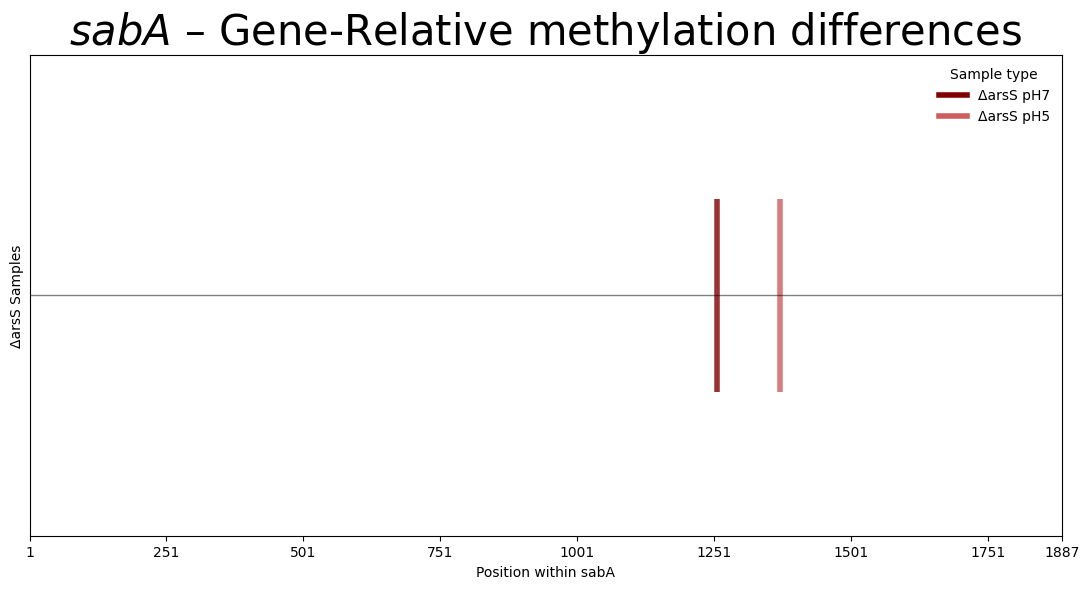

In [62]:
gene_start = 779011
gene_end = 780897


plot_single_bar_with_highlight_relative(ars_diff, gene_start, gene_end)


### babA Control Code

In [63]:
def plot_single_bar_with_highlight_relative(ctrl_diff, gene_start, gene_end):
    """
    Plot control sample differences along a gene using gene-relative (1-based)
    coordinates, with intermediate x-axis ticks and a legend.

    Parameters:
    ctrl_diff : DataFrame with columns ['start', 'end', 'sample']
    gene_start : genomic start of the gene
    gene_end   : genomic end of the gene
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.lines import Line2D

    # Filter data within gene boundaries
    filtered = ctrl_diff[
        (ctrl_diff['start'] >= gene_start) &
        (ctrl_diff['end'] <= gene_end)
    ].copy()

    if filtered.empty:
        print("No data in gene range")
        return

    # Convert genomic → gene-relative positions (+1 INCLUDED)
    filtered['relative_pos'] = filtered['start'] - gene_start + 1
    gene_length = gene_end - gene_start + 1

    # Create figure and axis (THIS is where `ax` comes from)
    fig, ax = plt.subplots(figsize=(11, 6))
    y_pos = 0

    # Plot tick marks
    for _, row in filtered.iterrows():
        if 'pH7' in str(row['sample']):
            color = 'darkgreen'
        elif 'pH5' in str(row['sample']):
            color = 'yellowgreen'
        else:
            color = 'gray'

        ax.plot(
            [row['relative_pos'], row['relative_pos']],
            [y_pos - 0.2, y_pos + 0.2],
            color=color,
            linewidth=4,
            alpha=0.8,
            solid_capstyle='butt'
        )

    # Baseline across gene
    ax.plot([1, gene_length], [y_pos, y_pos],
            color='black', linewidth=1, alpha=0.5)

    # Axis limits
    ax.set_xlim(1, gene_length)
    ax.set_ylim(-0.5, 0.5)

    # X-axis ticks: 1, intermediate values, and gene end
    tick_step = 250  # adjust if needed (e.g. 250, 1000)
    ticks = np.arange(1, gene_length + 1, tick_step)
    if gene_length not in ticks:
        ticks = np.append(ticks, gene_length)

    ax.set_xticks(ticks)
    ax.set_xticklabels([str(int(t)) for t in ticks])

    # Labels and title
    ax.set_xlabel('Coding Region of babA')
    ax.set_title('$\it{babA}$ – Gene-Relative methylation differences', fontsize=30)    
    ax.set_yticks([])
    ax.set_ylabel('Control Sample Differences')

    # Legend (key for sample type)
    legend_elements = [
        Line2D([0], [0], color='darkgreen', lw=4, label='Control pH7'),
        Line2D([0], [0], color='yellowgreen', lw=4, label='Control pH5')
    ]

    ax.legend(
        handles=legend_elements,
        title='Sample type',
        loc='upper right',
        frameon=False
    )

    plt.tight_layout()
    plt.show()


<>:70: SyntaxWarning: invalid escape sequence '\i'
<>:70: SyntaxWarning: invalid escape sequence '\i'
/var/folders/kw/19vs2__d3bl_tx91fly_4sg40000gn/T/ipykernel_25860/297971877.py:70: SyntaxWarning: invalid escape sequence '\i'
  ax.set_title('$\it{babA}$ – Gene-Relative methylation differences', fontsize=30)


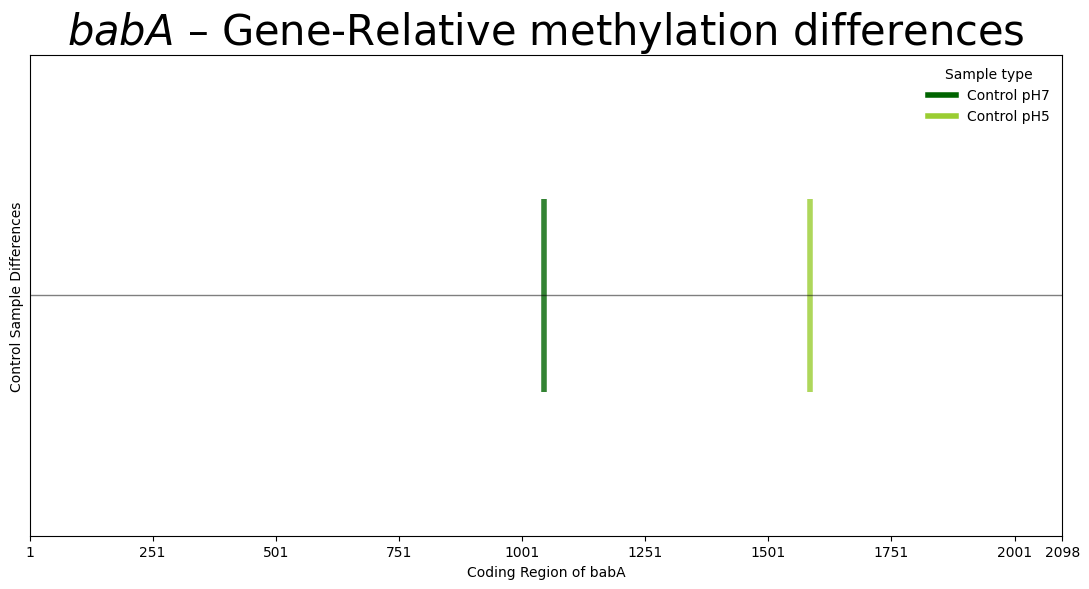

In [64]:
gene_start = 1317898
gene_end = 1319995


plot_single_bar_with_highlight_relative(ctrl_diff, gene_start, gene_end)

### babA ArsS Code

In [65]:
def plot_single_bar_with_highlight_relative(ars_diff, gene_start, gene_end):
    """
    Plot control sample differences along a gene using gene-relative (1-based)
    coordinates, with intermediate x-axis ticks and a legend.

    Parameters:
    ctrl_diff : DataFrame with columns ['start', 'end', 'sample']
    gene_start : genomic start of the gene
    gene_end   : genomic end of the gene
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.lines import Line2D

    # Filter data within gene boundaries
    filtered = ars_diff[
        (ars_diff['start'] >= gene_start) &
        (ars_diff['end'] <= gene_end)
    ].copy()

    if filtered.empty:
        print("No data in gene range")
        return

    # Convert genomic → gene-relative positions (+1 INCLUDED)
    filtered['relative_pos'] = filtered['start'] - gene_start + 1
    gene_length = gene_end - gene_start + 1

    # Create figure and axis (THIS is where `ax` comes from)
    fig, ax = plt.subplots(figsize=(11, 6))
    y_pos = 0

    for idx, row in filtered.iterrows():
        # Determine color based on sample type
        if 'pH7' in str(row['sample']):
            color = 'maroon'
            label = 'del_arsS pH7'
        elif 'pH5' in str(row['sample']):
            color = 'indianred' 
            label = 'del_arsS pH5'
        else:
            color = 'gray'
            label = 'other'
        ax.plot(
            [row['relative_pos'], row['relative_pos']],
            [y_pos - 0.2, y_pos + 0.2],
            color=color,
            linewidth=4,
            alpha=0.8,
            solid_capstyle='butt'
        )

    # Baseline across gene
    ax.plot([1, gene_length], [y_pos, y_pos],
            color='black', linewidth=1, alpha=0.5)

    # Axis limits
    ax.set_xlim(1, gene_length)
    ax.set_ylim(-0.5, 0.5)

    # X-axis ticks: 1, intermediate values, and gene end
    tick_step = 250  # adjust if needed (e.g. 250, 1000)
    ticks = np.arange(1, gene_length + 1, tick_step)
    if gene_length not in ticks:
        ticks = np.append(ticks, gene_length)

    ax.set_xticks(ticks)
    ax.set_xticklabels([str(int(t)) for t in ticks])

    # Labels and title
    ax.set_xlabel('Position within babA')
    ax.set_title('$\it{babA}$ – Gene-Relative methylation differences', fontsize=30)    
    ax.set_yticks([])
    ax.set_ylabel('ΔarsS Samples')
    # Legend (key for sample type)
    legend_elements = [
        Line2D([0], [0], color='maroon', lw=4, label='ΔarsS pH7'),
        Line2D([0], [0], color='indianred', lw=4, label='ΔarsS pH5')
    ]

    ax.legend(
        handles=legend_elements,
        title='Sample type',
        loc='upper right',
        frameon=False
    )

    plt.tight_layout()
    plt.show()


<>:72: SyntaxWarning: invalid escape sequence '\i'
<>:72: SyntaxWarning: invalid escape sequence '\i'
/var/folders/kw/19vs2__d3bl_tx91fly_4sg40000gn/T/ipykernel_25860/3969806903.py:72: SyntaxWarning: invalid escape sequence '\i'
  ax.set_title('$\it{babA}$ – Gene-Relative methylation differences', fontsize=30)


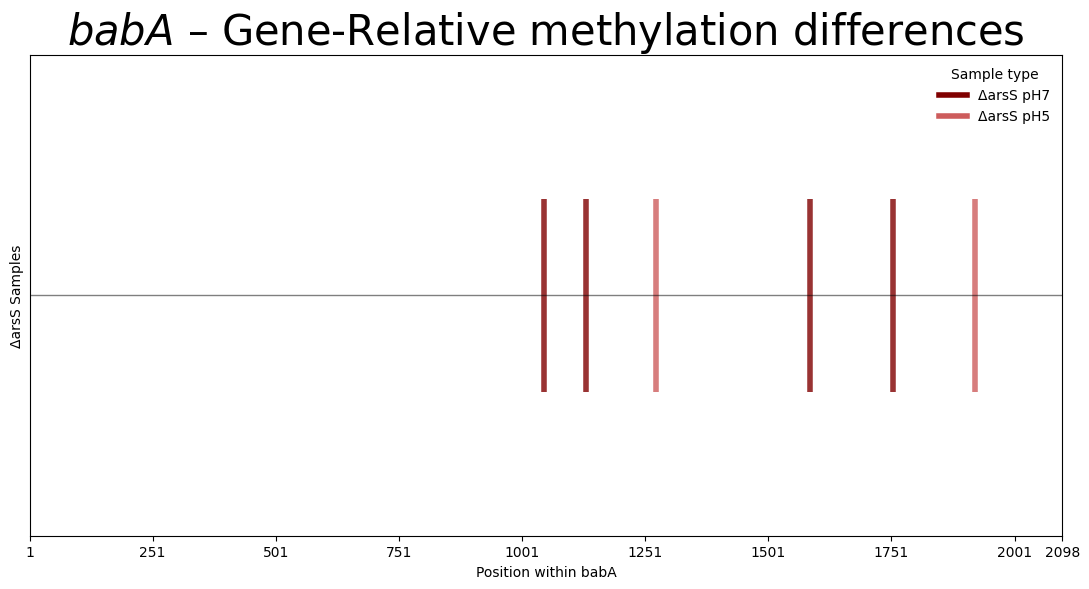

In [66]:
gene_start = 1317898
gene_end = 1319995


plot_single_bar_with_highlight_relative(ars_diff, gene_start, gene_end)

### cagPAI control code

In [67]:
def plot_single_bar_with_highlight_relative(ctrl_diff, gene_start, gene_end):
    """
    Plot control sample differences along a gene using gene-relative (1-based)
    coordinates, with intermediate x-axis ticks and a legend.

    Parameters:
    ctrl_diff : DataFrame with columns ['start', 'end', 'sample']
    gene_start : genomic start of the gene
    gene_end   : genomic end of the gene
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.lines import Line2D

    # Filter data within gene boundaries
    filtered = ctrl_diff[
        (ctrl_diff['start'] >= gene_start) &
        (ctrl_diff['end'] <= gene_end)
    ].copy()

    if filtered.empty:
        print("No data in gene range")
        return

    # Convert genomic → gene-relative positions (+1 INCLUDED)
    filtered['relative_pos'] = filtered['start'] - gene_start + 1
    gene_length = gene_end - gene_start + 1

    # Create figure and axis (THIS is where `ax` comes from)
    fig, ax = plt.subplots(figsize=(11, 6))
    y_pos = 0

    # Plot tick marks
    for _, row in filtered.iterrows():
        if 'pH7' in str(row['sample']):
            color = 'darkgreen'
        elif 'pH5' in str(row['sample']):
            color = 'yellowgreen'
        else:
            color = 'gray'

        ax.plot(
            [row['relative_pos'], row['relative_pos']],
            [y_pos - 0.2, y_pos + 0.2],
            color=color,
            linewidth=4,
            alpha=0.8,
            solid_capstyle='butt'
        )

    # Baseline across gene
    ax.plot([1, gene_length], [y_pos, y_pos],
            color='black', linewidth=1, alpha=0.5)

    # Axis limits
    ax.set_xlim(1, gene_length)
    ax.set_ylim(-0.5, 0.5)

    # X-axis ticks: 1, intermediate values, and gene end
    tick_step = 2410  # adjust if needed (e.g. 250, 1000)
    ticks = np.arange(1, gene_length + 1, tick_step)
    if gene_length not in ticks:
        ticks = np.append(ticks, gene_length)

    ax.set_xticks(ticks)
    ax.set_xticklabels([str(int(t)) for t in ticks])

    # Labels and title
    ax.set_xlabel('Coding Region of cagPAI')
    ax.set_title('$\it{cagPAI}$ – Gene-Relative methylation differences', fontsize=30)    
    ax.set_yticks([])
    ax.set_ylabel('Control Sample Differences')

    # Legend (key for sample type)
    legend_elements = [
        Line2D([0], [0], color='darkgreen', lw=4, label='Control pH7'),
        Line2D([0], [0], color='yellowgreen', lw=4, label='Control pH5')
    ]

    ax.legend(
        handles=legend_elements,
        title='Sample type',
        loc='upper right',
        frameon=False
    )

    plt.tight_layout()
    plt.show()


<>:70: SyntaxWarning: invalid escape sequence '\i'
<>:70: SyntaxWarning: invalid escape sequence '\i'
/var/folders/kw/19vs2__d3bl_tx91fly_4sg40000gn/T/ipykernel_25860/3329303160.py:70: SyntaxWarning: invalid escape sequence '\i'
  ax.set_title('$\it{cagPAI}$ – Gene-Relative methylation differences', fontsize=30)


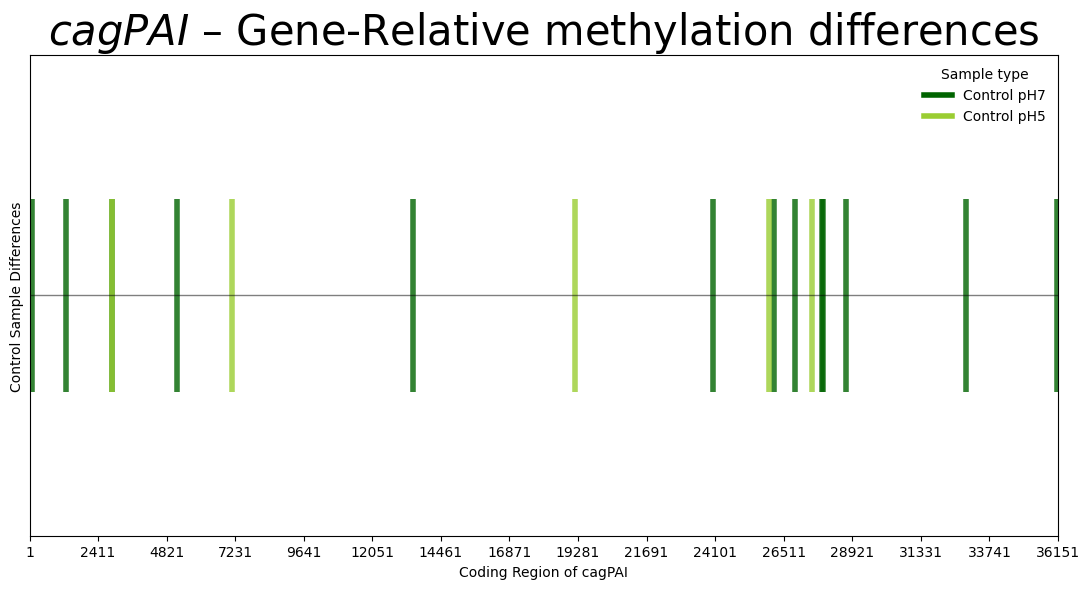

In [68]:
gene_start = 547328
gene_end = 583478


plot_single_bar_with_highlight_relative(ctrl_diff, gene_start, gene_end)

### CagPAI arsS code

In [69]:
def plot_single_bar_with_highlight_relative(ars_diff, gene_start, gene_end):
    """
    Plot control sample differences along a gene using gene-relative (1-based)
    coordinates, with intermediate x-axis ticks and a legend.

    Parameters:
    ctrl_diff : DataFrame with columns ['start', 'end', 'sample']
    gene_start : genomic start of the gene
    gene_end   : genomic end of the gene
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.lines import Line2D

    # Filter data within gene boundaries
    filtered = ars_diff[
        (ars_diff['start'] >= gene_start) &
        (ars_diff['end'] <= gene_end)
    ].copy()

    if filtered.empty:
        print("No data in gene range")
        return

    # Convert genomic → gene-relative positions (+1 INCLUDED)
    filtered['relative_pos'] = filtered['start'] - gene_start + 1
    gene_length = gene_end - gene_start + 1

    # Create figure and axis (THIS is where `ax` comes from)
    fig, ax = plt.subplots(figsize=(11, 6))
    y_pos = 0

    for idx, row in filtered.iterrows():
        # Determine color based on sample type
        if 'pH7' in str(row['sample']):
            color = 'maroon'
            label = 'del_arsS pH7'
        elif 'pH5' in str(row['sample']):
            color = 'indianred' 
            label = 'del_arsS pH5'
        else:
            color = 'gray'
            label = 'other'
        ax.plot(
            [row['relative_pos'], row['relative_pos']],
            [y_pos - 0.2, y_pos + 0.2],
            color=color,
            linewidth=4,
            alpha=0.8,
            solid_capstyle='butt'
        )

    # Baseline across gene
    ax.plot([1, gene_length], [y_pos, y_pos],
            color='black', linewidth=1, alpha=0.5)

    # Axis limits
    ax.set_xlim(1, gene_length)
    ax.set_ylim(-0.5, 0.5)

    # X-axis ticks: 1, intermediate values, and gene end
    tick_step = 2410  # adjust if needed (e.g. 250, 1000)
    ticks = np.arange(1, gene_length + 1, tick_step)
    if gene_length not in ticks:
        ticks = np.append(ticks, gene_length)

    ax.set_xticks(ticks)
    ax.set_xticklabels([str(int(t)) for t in ticks])

    # Labels and title
    ax.set_xlabel('Position within cagPAI')
    ax.set_title('$\it{cagPAI}$ – Gene-Relative methylation differences', fontsize=30)    
    ax.set_yticks([])
    ax.set_ylabel('ΔarsS Samples')
    # Legend (key for sample type)
    legend_elements = [
        Line2D([0], [0], color='maroon', lw=4, label='ΔarsS pH7'),
        Line2D([0], [0], color='indianred', lw=4, label='ΔarsS pH5')
    ]

    ax.legend(
        handles=legend_elements,
        title='Sample type',
        loc='upper right',
        frameon=False
    )

    plt.tight_layout()
    plt.show()


<>:72: SyntaxWarning: invalid escape sequence '\i'
<>:72: SyntaxWarning: invalid escape sequence '\i'
/var/folders/kw/19vs2__d3bl_tx91fly_4sg40000gn/T/ipykernel_25860/2494289394.py:72: SyntaxWarning: invalid escape sequence '\i'
  ax.set_title('$\it{cagPAI}$ – Gene-Relative methylation differences', fontsize=30)


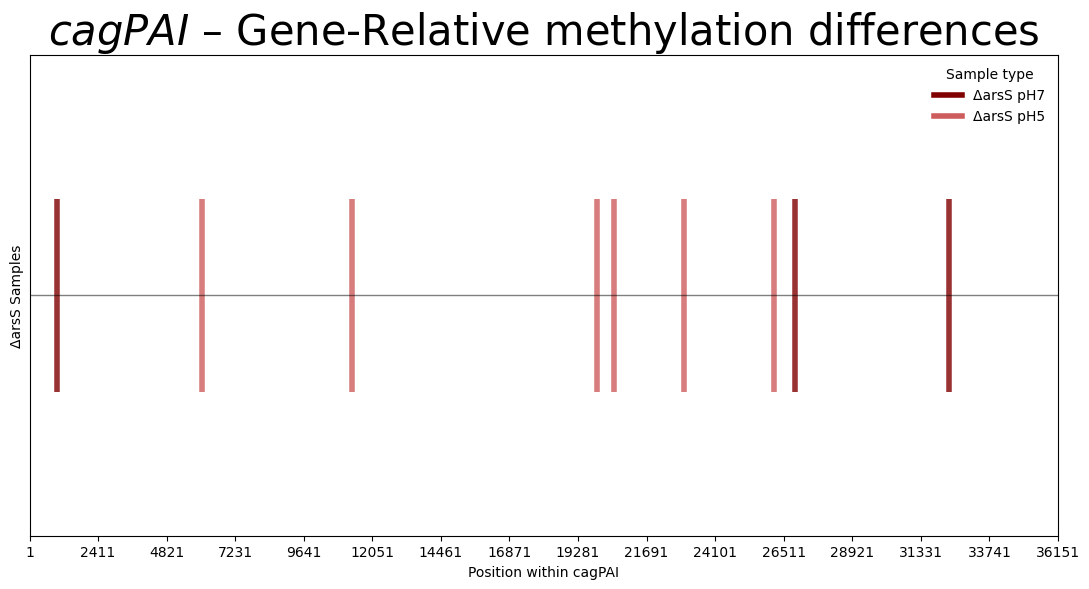

In [70]:
gene_start = 547328
gene_end = 583478


plot_single_bar_with_highlight_relative(ars_diff, gene_start, gene_end)